# MIT-BIH R-peak ground-truth benchmark (Windows)

This notebook tests one task only: **does an algorithm detect each cardiac beat at the correct time?** It does not calculate seizure probabilities and does not use CHB-MIT seizure labels.

The first audit uses MIT-BIH record `100` and its cardiologist-reviewed `100.atr` beat annotations. It compares the NeuroKit and Pan-Tompkins pipelines using one-to-one matching. The main QRS tolerance is `+/-75 ms`, following Kristof et al. (2024). Timing-error and RR-error distributions are reported separately because a successful QRS detection is not automatically precise enough for HRV.

**Evidence and data documentation**

- MIT-BIH Arrhythmia Database: https://physionet.org/content/mitdb/1.0.0/
- Open-source QRS detector benchmark: https://doi.org/10.1371/journal.pdig.0000538
- Pan and Tompkins (1985): https://doi.org/10.1109/TBME.1985.325532
- NeuroKit2: https://doi.org/10.3758/s13428-020-01516-y

Run the cells from top to bottom. Record `100` is a debugging and first-validation record, not sufficient evidence for selecting the final detector.

## Part 0 - Start Jupyter with the prepared project environment

From PowerShell:

```powershell
cd C:\Users\Salam\Documents\ECGdetector
.\feature_extraction\.venv\Scripts\python.exe -m jupyter lab
```

The next cell checks the packages without silently installing or upgrading anything.

In [1]:
from importlib.metadata import PackageNotFoundError, version

required_packages = ["neurokit2", "wfdb", "numpy", "pandas", "matplotlib"]
missing = []
for package in required_packages:
    try:
        print(f"{package:12s} {version(package)}")
    except PackageNotFoundError:
        missing.append(package)

if missing:
    raise RuntimeError(
        f"Missing packages: {missing}. Stop Jupyter and launch it with the "
        "project .venv command shown above."
    )

neurokit2    0.2.13
wfdb         4.3.1
numpy        2.4.2
pandas       2.3.3
matplotlib   3.10.8


In [2]:
from __future__ import annotations

import time
from pathlib import Path

import matplotlib.pyplot as plt
import neurokit2 as nk
import numpy as np
import pandas as pd
import wfdb
from IPython.display import display
from wfdb import processing

plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.max_columns", 40)
pd.set_option("display.width", 180)

print("NeuroKit2:", nk.__version__)
print("WFDB:", wfdb.__version__)

NeuroKit2: 0.2.13
WFDB: 4.3.1


## Part 1 - Locate the extracted MIT-BIH records

A WFDB record consists of files sharing the same stem. For record `100`:

- `100.hea` describes sampling rate, leads and storage;
- `100.dat` contains the two ECG signals;
- `100.atr` contains reference beat times and beat symbols.

The `.atr` file is the ground truth used here. Rhythm-change and signal-quality annotations are excluded from the beat list.

In [3]:
def find_project_root() -> Path:
    expected = Path(r"C:\Users\Salam\Documents\ECGdetector")
    candidates = [Path.cwd(), *Path.cwd().parents, expected]
    for candidate in candidates:
        if (candidate / "Datasets").is_dir() and (candidate / "feature_extraction").is_dir():
            return candidate.resolve()
    raise FileNotFoundError("Could not locate the ECGdetector project root.")

PROJECT_ROOT = find_project_root()
MITDB_DIR = (
    PROJECT_ROOT
    / "Datasets"
    / "mit-bih-arrhythmia-database-1.0"
    / "mit-bih-arrhythmia-database-1.0.0"
)
OUTPUT_DIR = PROJECT_ROOT / "output" / "rpeak_ground_truth_benchmark"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

required_100 = [MITDB_DIR / "100.hea", MITDB_DIR / "100.dat", MITDB_DIR / "100.atr"]
missing_100 = [path for path in required_100 if not path.exists()]
if missing_100:
    raise FileNotFoundError(f"Record 100 is incomplete: {missing_100}")

record_names = sorted(path.stem for path in MITDB_DIR.glob("[0-9][0-9][0-9].hea"))
print("Project root:", PROJECT_ROOT)
print("MIT-BIH directory:", MITDB_DIR)
print("Output directory:", OUTPUT_DIR)
print("Complete numeric record headers found:", len(record_names))
print(record_names)
assert len(record_names) == 48, "Expected the 48 MIT-BIH Arrhythmia records."

Project root: C:\Users\Salam\Documents\ECGdetector
MIT-BIH directory: C:\Users\Salam\Documents\ECGdetector\Datasets\mit-bih-arrhythmia-database-1.0\mit-bih-arrhythmia-database-1.0.0
Output directory: C:\Users\Salam\Documents\ECGdetector\output\rpeak_ground_truth_benchmark
Complete numeric record headers found: 48
['100', '101', '102', '103', '104', '105', '106', '107', '108', '109', '111', '112', '113', '114', '115', '116', '117', '118', '119', '121', '122', '123', '124', '200', '201', '202', '203', '205', '207', '208', '209', '210', '212', '213', '214', '215', '217', '219', '220', '221', '222', '223', '228', '230', '231', '232', '233', '234']


## Part 2 - Configuration

Keep the default settings for the first run. The first ECG channel is used because this matches the 2024 benchmark's MIT-BIH evaluation; it is MLII in most, but not all, records. `DURATION_SECONDS=None` means the complete 30-minute record is evaluated.

In [4]:
# -------------------------- EDITABLE SETTINGS --------------------------
RECORD_NAME = "100"
CHANNEL_INDEX = 0
START_SECONDS = 0.0
DURATION_SECONDS = None       # None = complete record
MATCH_TOLERANCE_MS = 75.0     # Kristof et al. 2024 QRS matching window
PLOT_START_SECONDS = 5.0
PLOT_DURATION_SECONDS = 10.0
DETECTOR_METHODS = {
    "NeuroKit": "neurokit",
    "Pan-Tompkins": "pantompkins1985",
}
# ----------------------------------------------------------------------

## Part 3 - Load ECG and reference beats

MIT-BIH annotation files contain both beat symbols and non-beat events. The set below retains the standard beat classes and removes rhythm-change markers such as `+`. The displayed symbol table lets us audit exactly what was retained rather than assuming every annotation is a heartbeat.

In [5]:
# Standard WFDB beat annotation symbols. Non-beat annotations such as '+', '~',
# '[', and ']' are intentionally absent.
BEAT_SYMBOLS = {"N", "L", "R", "B", "A", "a", "J", "S",
                "V", "r", "F", "e", "j", "n", "E", "/",
                "f", "Q", "?"}

record_path = MITDB_DIR / RECORD_NAME
header = wfdb.rdheader(str(record_path))
fs = float(header.fs)
start_sample = int(round(START_SECONDS * fs))
if DURATION_SECONDS is None:
    end_sample = int(header.sig_len)
else:
    end_sample = min(int(header.sig_len), start_sample + int(round(DURATION_SECONDS * fs)))

record = wfdb.rdrecord(
    str(record_path),
    sampfrom=start_sample,
    sampto=end_sample,
    channels=[CHANNEL_INDEX],
    physical=True,
)
ecg = np.asarray(record.p_signal[:, 0], dtype=np.float64)
annotation = wfdb.rdann(str(record_path), "atr")
ann_samples = np.asarray(annotation.sample, dtype=np.int64)
ann_symbols = np.asarray(annotation.symbol, dtype=object)
in_segment = (ann_samples >= start_sample) & (ann_samples < end_sample)
is_beat = np.asarray([symbol in BEAT_SYMBOLS for symbol in ann_symbols], dtype=bool)
keep = in_segment & is_beat
reference_peaks = ann_samples[keep] - start_sample
reference_symbols = ann_symbols[keep]

if not np.all(np.isfinite(ecg)):
    raise ValueError("The selected ECG contains non-finite values.")
if reference_peaks.size == 0:
    raise ValueError("No reference beat annotations were found in the selected segment.")

symbol_counts = (
    pd.Series(reference_symbols, name="symbol")
    .value_counts()
    .rename_axis("beat_symbol")
    .reset_index(name="count")
)
print(f"Record: {RECORD_NAME}")
print(f"Lead: {record.sig_name[0]} | unit: {record.units[0]} | fs: {fs:g} Hz")
print(f"Segment: {start_sample/fs:.1f} to {end_sample/fs:.1f} s")
print(f"ECG samples: {ecg.size:,} | reference beats retained: {reference_peaks.size:,}")
display(symbol_counts)

Record: 100
Lead: MLII | unit: mV | fs: 360 Hz
Segment: 0.0 to 1805.6 s
ECG samples: 650,000 | reference beats retained: 2,273


,beat_symbol,count
0,N,2239
1,A,33
2,V,1


### Ground-truth plot

The black diamonds are positions read from `100.atr`; they are not produced by either detector. This is the information that was missing from the CHB04 plot.

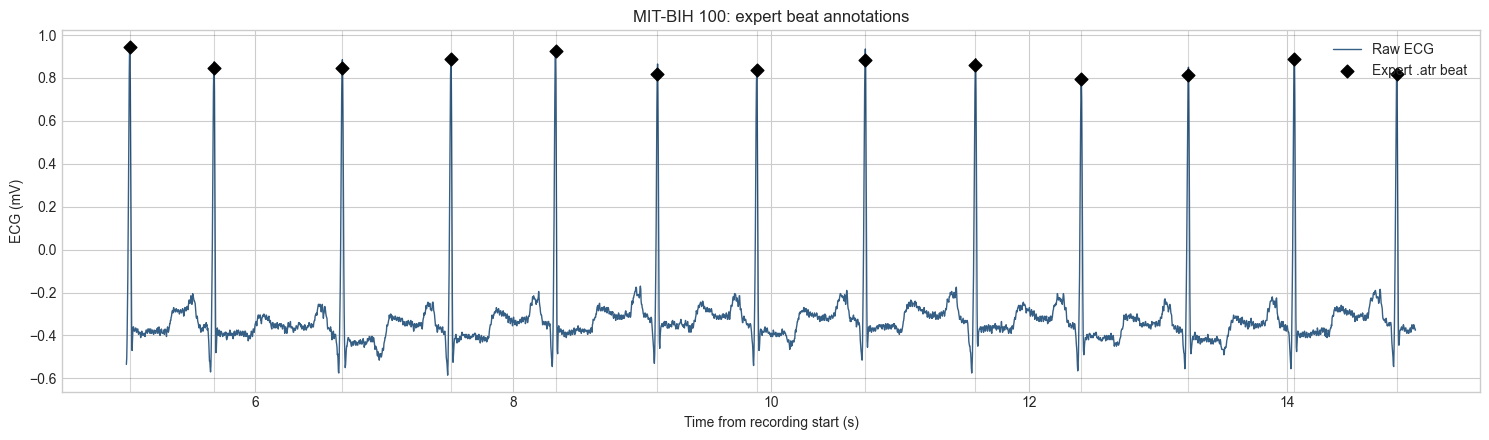

In [6]:
def samples_in_window(samples: np.ndarray, left: int, right: int) -> np.ndarray:
    samples = np.asarray(samples, dtype=np.int64)
    return samples[(samples >= left) & (samples < right)]

plot_left = max(0, int(round((PLOT_START_SECONDS - START_SECONDS) * fs)))
plot_right = min(ecg.size, plot_left + int(round(PLOT_DURATION_SECONDS * fs)))
plot_samples = np.arange(plot_left, plot_right)
plot_time = START_SECONDS + plot_samples / fs
ref_plot = samples_in_window(reference_peaks, plot_left, plot_right)

fig, ax = plt.subplots(figsize=(15, 4.5))
ax.plot(plot_time, ecg[plot_samples], color="#365f86", lw=1.0, label="Raw ECG")
ax.scatter(START_SECONDS + ref_plot / fs, ecg[ref_plot], marker="D", s=42,
           color="black", zorder=4, label="Expert .atr beat")
for sample in ref_plot:
    ax.axvline(START_SECONDS + sample / fs, color="black", alpha=0.16, lw=0.8)
ax.set(title=f"MIT-BIH {RECORD_NAME}: expert beat annotations",
       xlabel="Time from recording start (s)", ylabel=f"ECG ({record.units[0]})")
ax.legend(loc="upper right")
plt.tight_layout()
plt.show()

## Part 4 - Run the two fixed detector pipelines

Each method receives the same physical ECG lead. Method-specific NeuroKit cleaning is followed by method-specific peak detection. Artifact correction is disabled so that the benchmark measures the raw detector output rather than a second correction algorithm. No threshold is trained on record `100`.

In [7]:
def detect_with_neurokit(signal: np.ndarray, sampling_rate: float, method: str) -> tuple[np.ndarray, np.ndarray, float]:
    started = time.perf_counter()
    cleaned = np.asarray(
        nk.ecg_clean(signal, sampling_rate=sampling_rate, method=method),
        dtype=np.float64,
    )
    _, info = nk.ecg_peaks(
        cleaned,
        sampling_rate=sampling_rate,
        method=method,
        correct_artifacts=False,
    )
    peaks = np.asarray(info["ECG_R_Peaks"], dtype=np.int64)
    elapsed = time.perf_counter() - started
    return cleaned, peaks, elapsed

detector_outputs = {}
for label, method in DETECTOR_METHODS.items():
    cleaned, peaks, elapsed = detect_with_neurokit(ecg, fs, method)
    detector_outputs[label] = {"method": method, "cleaned": cleaned, "peaks": peaks, "seconds": elapsed}
    print(f"{label:14s}: {peaks.size:5d} candidates in {elapsed:.3f} s")

NeuroKit      :  2270 candidates in 0.258 s
Pan-Tompkins  :  2272 candidates in 0.129 s


## Part 5 - One-to-one comparison with ground truth

A detection within `+/-75 ms` of a reference beat can become one true positive. A detection cannot be reused for two reference beats. Remaining reference beats are false negatives; remaining detector outputs are false positives.

- Sensitivity = TP / (TP + FN): how many real beats were found.
- PPV = TP / (TP + FP): how many reported beats were real.
- F1 = harmonic mean of sensitivity and PPV.

These are beat-detection metrics, not seizure-classification metrics.

In [8]:
def compare_to_reference(reference: np.ndarray, detected: np.ndarray, sampling_rate: float, tolerance_ms: float):
    tolerance_samples = max(1, int(round(tolerance_ms * sampling_rate / 1000.0)))
    comparison = processing.compare_annotations(
        np.asarray(reference, dtype=np.int64),
        np.asarray(detected, dtype=np.int64),
        window_width=tolerance_samples,
    )
    precision = comparison.positive_predictivity
    sensitivity = comparison.sensitivity
    f1 = 2 * precision * sensitivity / (precision + sensitivity) if precision + sensitivity else np.nan
    timing_error_ms = (comparison.matched_test_sample - comparison.matched_ref_sample) * 1000.0 / sampling_rate
    absolute_timing_error_ms = np.abs(timing_error_ms)
    return comparison, timing_error_ms, {
        "reference_beats": int(comparison.n_ref),
        "detected_beats": int(comparison.n_test),
        "TP": int(comparison.tp),
        "FP": int(comparison.fp),
        "FN": int(comparison.fn),
        "sensitivity": float(sensitivity),
        "PPV": float(precision),
        "F1": float(f1),
        "median_abs_timing_error_ms": float(np.median(absolute_timing_error_ms)) if absolute_timing_error_ms.size else np.nan,
        "p95_abs_timing_error_ms": float(np.percentile(absolute_timing_error_ms, 95)) if absolute_timing_error_ms.size else np.nan,
        "runtime_s": np.nan,
    }

comparisons = {}
metric_rows = []
for label, output in detector_outputs.items():
    comparison, timing_error_ms, metrics = compare_to_reference(
        reference_peaks, output["peaks"], fs, MATCH_TOLERANCE_MS
    )
    metrics["detector"] = label
    metrics["runtime_s"] = output["seconds"]
    comparisons[label] = {"comparison": comparison, "timing_error_ms": timing_error_ms}
    metric_rows.append(metrics)

metrics_df = pd.DataFrame(metric_rows).set_index("detector")
display(metrics_df.round(4))
metrics_df.to_csv(OUTPUT_DIR / f"record_{RECORD_NAME}_detector_metrics.csv")
print("Saved:", OUTPUT_DIR / f"record_{RECORD_NAME}_detector_metrics.csv")

,reference_beats,detected_beats,TP,FP,FN,sensitivity,PPV,F1,median_abs_timing_error_ms,p95_abs_timing_error_ms,runtime_s
detector,,,,,,,,,,,
NeuroKit,2273,2270,2270,0,3,0.9987,1.0000,0.9993,0.0000,2.7778,0.2575
Pan-Tompkins,2273,2272,1945,327,328,0.8557,0.8561,0.8559,38.8889,41.6667,0.1287


Saved: C:\Users\Salam\Documents\ECGdetector\output\rpeak_ground_truth_benchmark\record_100_detector_metrics.csv


### Clear three-panel marker audit

The expert reference and the two algorithms are separated into panels to prevent the overlapping-marker problem. Black vertical lines are the expert beats. Colored markers are detector outputs. Red outlined circles indicate unmatched detector outputs, and magenta dashed lines indicate missed expert beats.

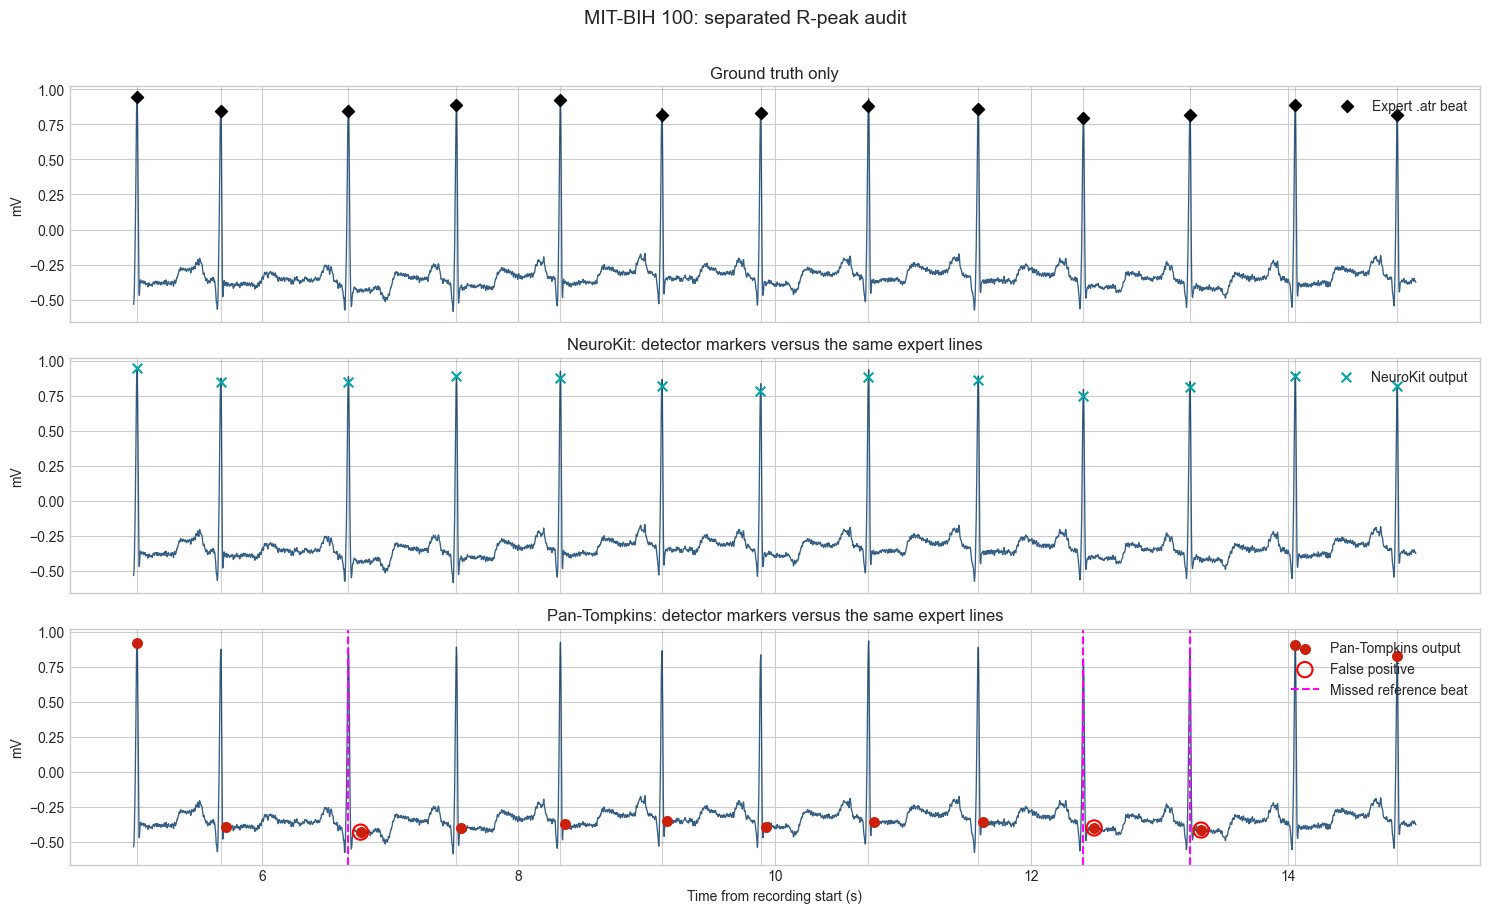

In [9]:
def plot_detector_audit(center_start_s: float, duration_s: float = 10.0):
    left = max(0, int(round((center_start_s - START_SECONDS) * fs)))
    right = min(ecg.size, left + int(round(duration_s * fs)))
    x_samples = np.arange(left, right)
    x_time = START_SECONDS + x_samples / fs
    ref_here = samples_in_window(reference_peaks, left, right)

    fig, axes = plt.subplots(3, 1, figsize=(15, 9), sharex=True, sharey=True)
    for ax in axes:
        ax.plot(x_time, ecg[x_samples], color="#365f86", lw=0.95)
        for sample in ref_here:
            ax.axvline(START_SECONDS + sample / fs, color="black", alpha=0.18, lw=0.8)
        ax.set_ylabel(record.units[0])

    axes[0].scatter(START_SECONDS + ref_here / fs, ecg[ref_here], color="black",
                    marker="D", s=38, zorder=4, label="Expert .atr beat")
    axes[0].set_title("Ground truth only")
    axes[0].legend(loc="upper right")

    colors = {"NeuroKit": "#00a6a6", "Pan-Tompkins": "#cc1f0c"}
    for ax, label in zip(axes[1:], ["NeuroKit", "Pan-Tompkins"]):
        output = detector_outputs[label]
        comparison = comparisons[label]["comparison"]
        detected_here = samples_in_window(output["peaks"], left, right)
        false_here = samples_in_window(comparison.unmatched_test_sample, left, right)
        missed_here = samples_in_window(comparison.unmatched_ref_sample, left, right)
        ax.scatter(START_SECONDS + detected_here / fs, ecg[detected_here], color=colors[label],
                   marker="x" if label == "NeuroKit" else "o", s=48, zorder=4, label=f"{label} output")
        if false_here.size:
            ax.scatter(START_SECONDS + false_here / fs, ecg[false_here], facecolors="none",
                       edgecolors="red", marker="o", s=120, lw=1.5, zorder=5, label="False positive")
        for k, sample in enumerate(missed_here):
            ax.axvline(START_SECONDS + sample / fs, color="magenta", ls="--", lw=1.5,
                       label="Missed reference beat" if k == 0 else None)
        ax.set_title(f"{label}: detector markers versus the same expert lines")
        ax.legend(loc="upper right")

    axes[-1].set_xlabel("Time from recording start (s)")
    fig.suptitle(f"MIT-BIH {RECORD_NAME}: separated R-peak audit", y=1.01, fontsize=14)
    plt.tight_layout()
    plt.show()

plot_detector_audit(PLOT_START_SECONDS, PLOT_DURATION_SECONDS)

## Part 6 - Timing precision and RR error

The `+/-75 ms` rule answers whether the detector landed on the same QRS complex. The histogram below asks the stricter HRV question: how far did its timestamp move from the expert reference?

RR error is calculated only between pairs that are consecutive in both the reference sequence and detector sequence. This prevents a missed or extra beat from being incorrectly interpreted as an ordinary RR-timing error.

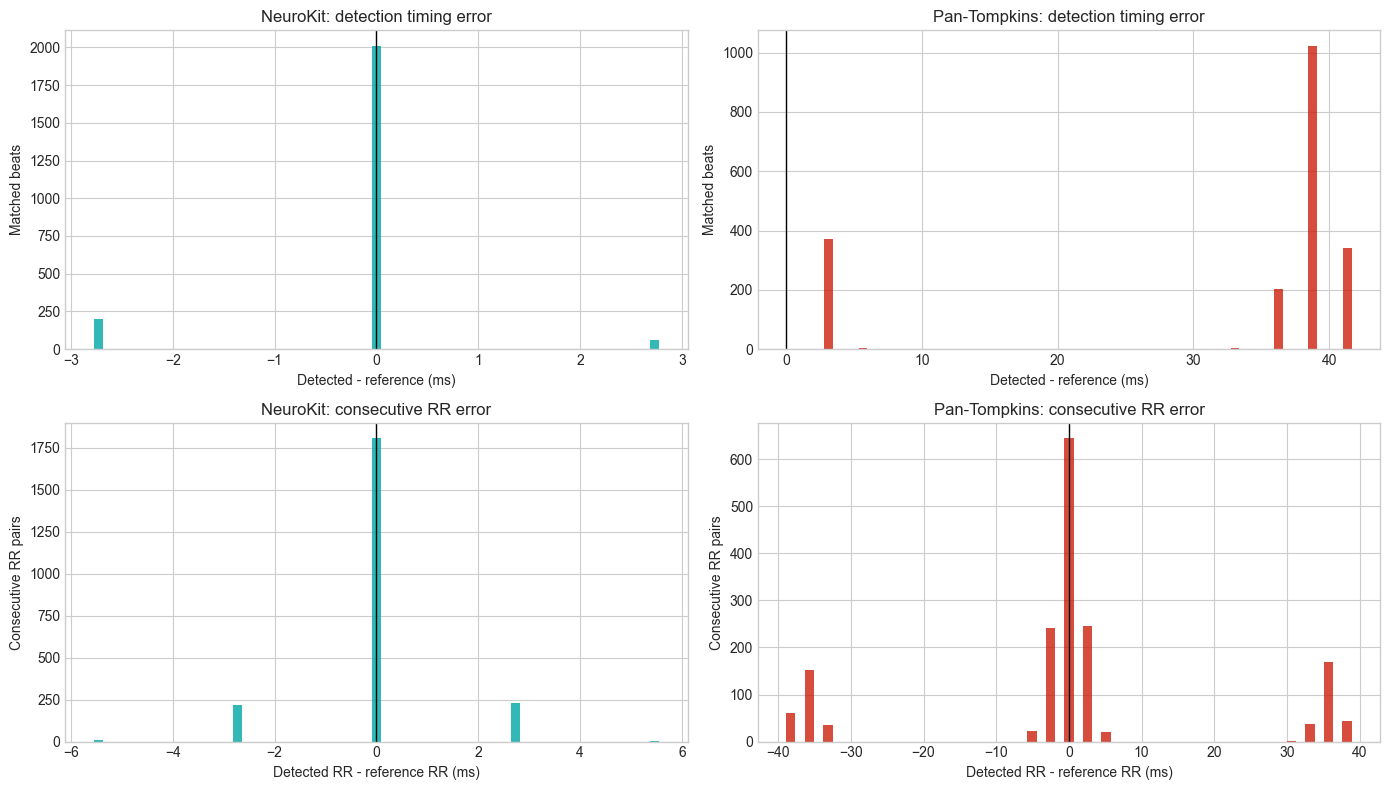

,matched_beats,median_signed_timing_error_ms,median_abs_timing_error_ms,p95_abs_timing_error_ms,consecutive_rr_pairs,median_abs_rr_error_ms,p95_abs_rr_error_ms
detector,,,,,,,
NeuroKit,2270,0.000,0.000,2.778,2268,0.000,2.778
Pan-Tompkins,1945,38.889,38.889,41.667,1675,2.778,38.889


In [10]:
def consecutive_rr_errors_ms(comparison, sampling_rate: float) -> np.ndarray:
    consecutive_reference = np.diff(comparison.matched_ref_inds) == 1
    consecutive_detector = np.diff(comparison.matched_test_inds) == 1
    valid = consecutive_reference & consecutive_detector
    reference_rr_ms = np.diff(comparison.matched_ref_sample) * 1000.0 / sampling_rate
    detector_rr_ms = np.diff(comparison.matched_test_sample) * 1000.0 / sampling_rate
    return (detector_rr_ms - reference_rr_ms)[valid]

precision_rows = []
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
colors = {"NeuroKit": "#00a6a6", "Pan-Tompkins": "#cc1f0c"}
for column, label in enumerate(["NeuroKit", "Pan-Tompkins"]):
    timing_error = comparisons[label]["timing_error_ms"]
    rr_error = consecutive_rr_errors_ms(comparisons[label]["comparison"], fs)
    axes[0, column].hist(timing_error, bins=61, color=colors[label], alpha=0.8)
    axes[0, column].axvline(0, color="black", lw=1)
    axes[0, column].set(title=f"{label}: detection timing error", xlabel="Detected - reference (ms)", ylabel="Matched beats")
    axes[1, column].hist(rr_error, bins=61, color=colors[label], alpha=0.8)
    axes[1, column].axvline(0, color="black", lw=1)
    axes[1, column].set(title=f"{label}: consecutive RR error", xlabel="Detected RR - reference RR (ms)", ylabel="Consecutive RR pairs")
    precision_rows.append({
        "detector": label,
        "matched_beats": timing_error.size,
        "median_signed_timing_error_ms": np.median(timing_error),
        "median_abs_timing_error_ms": np.median(np.abs(timing_error)),
        "p95_abs_timing_error_ms": np.percentile(np.abs(timing_error), 95),
        "consecutive_rr_pairs": rr_error.size,
        "median_abs_rr_error_ms": np.median(np.abs(rr_error)) if rr_error.size else np.nan,
        "p95_abs_rr_error_ms": np.percentile(np.abs(rr_error), 95) if rr_error.size else np.nan,
    })
plt.tight_layout()
plt.show()

precision_df = pd.DataFrame(precision_rows).set_index("detector")
display(precision_df.round(3))
precision_df.to_csv(OUTPUT_DIR / f"record_{RECORD_NAME}_timing_and_rr_precision.csv")

## Part 7 - Inspect the first actual failure

Summary scores can conceal why a detector failed. This cell finds the first false positive or missed beat and plots a four-second window around it. If the selected detector has no failure, it says so explicitly.

First NeuroKit mismatch is near 0.214 s.


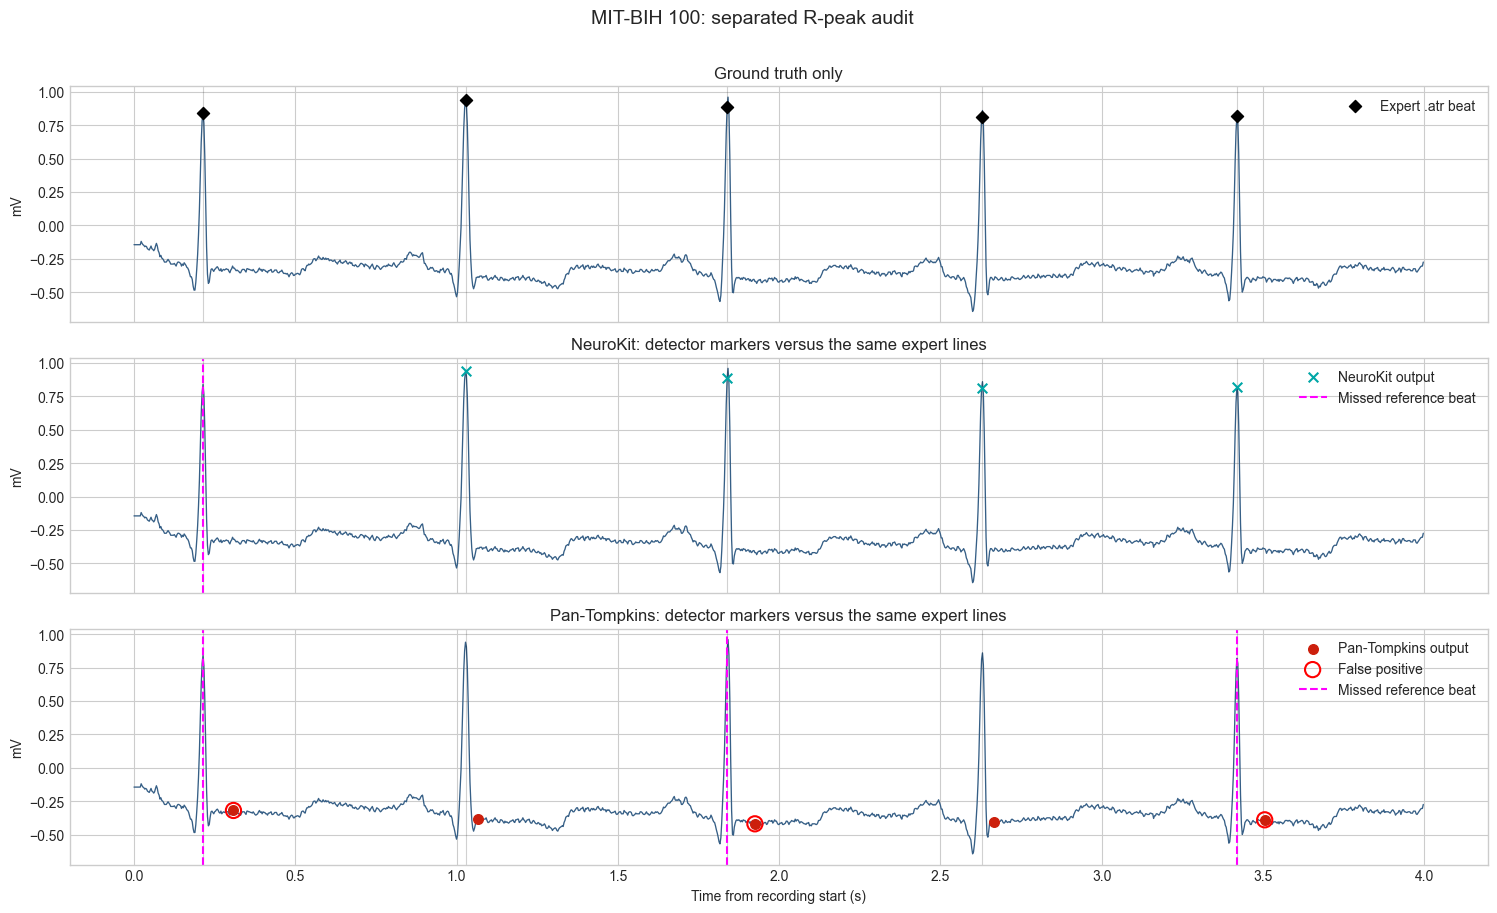

In [11]:
DETECTOR_TO_INSPECT = "NeuroKit"  # change to "Pan-Tompkins" when desired
comparison = comparisons[DETECTOR_TO_INSPECT]["comparison"]
failure_samples = np.sort(np.concatenate([comparison.unmatched_ref_sample, comparison.unmatched_test_sample]))
if failure_samples.size:
    failure_time_s = START_SECONDS + failure_samples[0] / fs
    print(f"First {DETECTOR_TO_INSPECT} mismatch is near {failure_time_s:.3f} s.")
    plot_detector_audit(max(START_SECONDS, failure_time_s - 2.0), duration_s=4.0)
else:
    print(f"No unmatched beat was found for {DETECTOR_TO_INSPECT} in this segment.")

## Part 8 - Full 48-record benchmark

Do not select a final detector from record `100` alone. After the single-record plots and metrics make sense, change `RUN_FULL_DATABASE` to `True`. The loop reads one record at a time, uses channel 0, retains beat annotations, evaluates both unchanged algorithms at `+/-75 ms`, and saves per-record results.

This is still an external arrhythmia benchmark. It establishes general beat-detection behavior but does not replace later patient-specific annotation of representative CHB04 ECG.

In [14]:
RUN_FULL_DATABASE = True  # change to True only after record 100 is understood

def benchmark_complete_record(record_name: str, channel_index: int = 0) -> list[dict]:
    path = MITDB_DIR / record_name
    rec = wfdb.rdrecord(str(path), channels=[channel_index], physical=True)
    signal = np.asarray(rec.p_signal[:, 0], dtype=np.float64)
    record_fs = float(rec.fs)
    ann = wfdb.rdann(str(path), "atr")
    beat_mask = np.asarray([symbol in BEAT_SYMBOLS for symbol in ann.symbol], dtype=bool)
    reference = np.asarray(ann.sample, dtype=np.int64)[beat_mask]
    rows = []
    for label, method in DETECTOR_METHODS.items():
        try:
            _, detected, elapsed = detect_with_neurokit(signal, record_fs, method)
            _, _, metrics = compare_to_reference(reference, detected, record_fs, MATCH_TOLERANCE_MS)
            metrics.update({
                "record": record_name,
                "lead": rec.sig_name[0],
                "detector": label,
                "runtime_s": elapsed,
                "error": None,
            })
        except Exception as exc:
            metrics = {
                "record": record_name, "lead": rec.sig_name[0], "detector": label,
                "reference_beats": reference.size, "detected_beats": np.nan,
                "TP": np.nan, "FP": np.nan, "FN": np.nan,
                "sensitivity": np.nan, "PPV": np.nan, "F1": np.nan,
                "median_abs_timing_error_ms": np.nan, "p95_abs_timing_error_ms": np.nan,
                "runtime_s": np.nan, "error": repr(exc),
            }
        rows.append(metrics)
    return rows

if RUN_FULL_DATABASE:
    full_rows = []
    for index, name in enumerate(record_names, start=1):
        print(f"[{index:02d}/{len(record_names)}] {name}")
        full_rows.extend(benchmark_complete_record(name))
    full_results_df = pd.DataFrame(full_rows)
    full_results_path = OUTPUT_DIR / "mitdb_48_record_detector_results.csv"
    full_results_df.to_csv(full_results_path, index=False)
    display(full_results_df.head())
    print("Saved:", full_results_path)
else:
    print("Full-database run skipped. Set RUN_FULL_DATABASE=True after auditing record 100.")

[01/48] 100
[02/48] 101
[03/48] 102
[04/48] 103
[05/48] 104
[06/48] 105
[07/48] 106
[08/48] 107
[09/48] 108
[10/48] 109
[11/48] 111
[12/48] 112
[13/48] 113
[14/48] 114
[15/48] 115
[16/48] 116
[17/48] 117
[18/48] 118
[19/48] 119
[20/48] 121
[21/48] 122
[22/48] 123
[23/48] 124
[24/48] 200
[25/48] 201
[26/48] 202
[27/48] 203
[28/48] 205
[29/48] 207
[30/48] 208
[31/48] 209
[32/48] 210
[33/48] 212
[34/48] 213
[35/48] 214
[36/48] 215
[37/48] 217
[38/48] 219
[39/48] 220
[40/48] 221
[41/48] 222
[42/48] 223
[43/48] 228
[44/48] 230
[45/48] 231
[46/48] 232
[47/48] 233
[48/48] 234


,reference_beats,detected_beats,TP,FP,FN,sensitivity,PPV,F1,median_abs_timing_error_ms,p95_abs_timing_error_ms,runtime_s,record,lead,detector,error
0,2273,2270,2270,0,3,0.998680,1.000000,0.999340,0.000000,2.777778,0.235027,100,MLII,NeuroKit,None
1,2273,2272,1945,327,328,0.855697,0.856074,0.855886,38.888889,41.666667,0.099596,100,MLII,Pan-Tompkins,None
2,1865,1865,1862,3,3,0.998391,0.998391,0.998391,0.000000,2.777778,0.194422,101,MLII,NeuroKit,None
3,1865,1868,1406,462,459,0.753887,0.752677,0.753282,47.222222,47.222222,0.111171,101,MLII,Pan-Tompkins,None
4,2187,2186,2173,13,14,0.993599,0.994053,0.993826,0.000000,2.777778,0.242565,102,V5,NeuroKit,None


Saved: C:\Users\Salam\Documents\ECGdetector\output\rpeak_ground_truth_benchmark\mitdb_48_record_detector_results.csv


## Part 9 - Aggregate the full benchmark without hiding bad records

When the full run exists, this reports both:

1. pooled beat counts, which weight records containing more beats more heavily; and
2. median and worst-record F1, which reveal whether strong overall performance hides failure on particular morphologies.

A final HRV detector should not be selected from pooled F1 alone. Timing and RR precision, failure records, noise robustness, and later CHB04 manual audit all remain required.

In [15]:
if RUN_FULL_DATABASE:
    summary_rows = []
    valid = full_results_df[full_results_df["error"].isna()].copy()
    for detector, group in valid.groupby("detector"):
        tp, fp, fn = group[["TP", "FP", "FN"]].sum()
        pooled_sensitivity = tp / (tp + fn)
        pooled_ppv = tp / (tp + fp)
        pooled_f1 = 2 * pooled_sensitivity * pooled_ppv / (pooled_sensitivity + pooled_ppv)
        worst = group.loc[group["F1"].idxmin()]
        summary_rows.append({
            "detector": detector,
            "successful_records": len(group),
            "pooled_sensitivity": pooled_sensitivity,
            "pooled_PPV": pooled_ppv,
            "pooled_F1": pooled_f1,
            "median_record_F1": group["F1"].median(),
            "worst_record": worst["record"],
            "worst_record_F1": worst["F1"],
            "median_of_record_p95_timing_ms": group["p95_abs_timing_error_ms"].median(),
        })
    full_summary_df = pd.DataFrame(summary_rows).set_index("detector")
    display(full_summary_df.round(5))
    full_summary_df.to_csv(OUTPUT_DIR / "mitdb_48_record_detector_summary.csv")
else:
    print("No full-database results yet.")

,successful_records,pooled_sensitivity,pooled_PPV,pooled_F1,median_record_F1,worst_record,worst_record_F1,median_of_record_p95_timing_ms
detector,,,,,,,,
NeuroKit,48,0.98320,0.97731,0.98025,0.99840,113,0.77528,2.77778
Pan-Tompkins,48,0.56817,0.56655,0.56736,0.54716,115,0.20123,47.22222


## Decision boundary

This notebook does **not** automatically declare a winner. Evidence required before accepting timestamps for the RR/HRV branch:

1. high sensitivity and PPV across all MIT-BIH records;
2. small and stable timing and consecutive-RR error;
3. explicit review of worst records rather than only the pooled result;
4. a separate MIT-BIH Noise Stress Test evaluation;
5. manual beat annotation of representative clean and contaminated CHB04 ECG segments.

Passing MIT-BIH validates general arrhythmia-record beat detection. It does not prove seizure-period or patient-specific validity.